In [3]:
from helper import *

# Load the full dataset that contains all the cities and populations, create new columns
full_dataset = pd.read_csv("../data/raw/SNIS_2020_raw.csv")
full_dataset['Attended Population'] = full_dataset['Attended Population (sewer)']
full_dataset['Served Population'] = full_dataset['Attended Population (sewer)']
full_dataset = full_dataset.fillna(0)

# Load all clean datasets (remember to re-run the clean_data.py code if the raw data files change)
snis_sewer, snis_water, ibnet_sewer, ibnet_water = load_datasets()

# Create cross-sectional versions of snis sewer and water
CS_YEAR = 2020
snis_sewer_cs, snis_water_cs = snis_sewer[snis_sewer['Year'] == CS_YEAR], snis_water[snis_water['Year'] == CS_YEAR]

In [4]:
# You can change the n value here to determine the bootstrap size
N = 10

x, y, y_lower, y_upper = [], [], [], []
for year in range(2005, 2021):
    year_cs = snis_sewer[snis_sewer['Year'] == year].copy()
    _, full_length_average, lower_bound, upper_bound = simulate_full_bootstrap(year_cs, full_dataset,
                                                                               growth=False, n=N)
    x.append(year)
    y.append(full_length_average)
    y_lower.append(lower_bound)
    y_upper.append(upper_bound)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

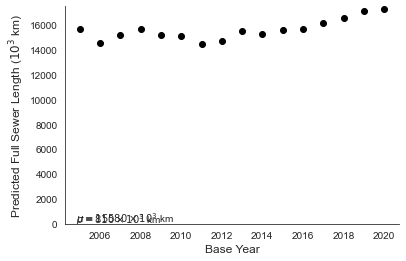

In [6]:
# Calculate the errors
y_err_upper = np.array(y_upper) - np.array(y)
y_err_lower = np.array(y) - np.array(y_lower)

# Plot the data
data = pd.DataFrame({'x': x, 'y': np.array(y)/1000, 'y_err_upper': y_err_upper/1000, 'y_err_lower': y_err_lower/1000})
sns.set_style('white')
plt.errorbar(data['x'], data['y'], yerr=[data['y_err_lower'], data['y_err_upper']], fmt='o', color='black', ecolor='gray', elinewidth=1, capsize=2)
plt.ylim(0)

# Add information to the chart
estimate_mean = np.mean(y)/1000
estimate_std = np.std(y)/1000

plt.text(2004.8, 100, rf'$\mu = {estimate_mean:.0f} \times 10^3$ km')
plt.text(2004.8, 40, rf'$\sigma = {estimate_std:.0f} \times 10^3$ km')

labels(rf'Base Year', rf'Predicted Full Sewer Length ($10^3$ km)')

sns.despine()
plt.show()